In [ ]:
!pip install torch torchvision transformers captum gradio scipy pillow

In [ ]:
"""
LVLM-Interpret: Integrated Gradients Feature Attribution with Gradio
A complete Python implementation using PyTorch, Captum, and Gradio
"""

import gradio as gr
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from captum.attr import IntegratedGradients, LayerIntegratedGradients
from transformers import BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from io import BytesIO
import traceback
import sys

# Global model variables
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = None
model = None

def load_model():
    """Load the BLIP model for image captioning"""
    global processor, model
    try:
        if model is None:
            print("=" * 60)
            print("Loading BLIP model...")
            print(f"Device: {device}")
            print("=" * 60)

            processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
            print("✓ Processor loaded successfully")

            model = BlipForConditionalGeneration.from_pretrained(
                "Salesforce/blip-image-captioning-base"
            ).to(device)
            model.eval()
            print(f"✓ Model loaded successfully on {device}")
            print("=" * 60)
        return processor, model
    except Exception as e:
        print("\n" + "!" * 60)
        print("ERROR in load_model():")
        print("!" * 60)
        traceback.print_exc()
        print("!" * 60 + "\n")
        raise


def compute_integrated_gradients(image_pil, caption, target_token_idx, n_steps=50):
    """
    Compute integrated gradients for a specific token in the caption

    Args:
        image_pil: PIL Image
        caption: Generated caption string
        target_token_idx: Index of the token to compute attributions for
        n_steps: Number of steps for integrated gradients

    Returns:
        attribution_map: numpy array of attributions
    """
    try:
        print("\n" + "-" * 60)
        print("Starting compute_integrated_gradients()")
        print(f"Caption: {caption}")
        print(f"Target token index: {target_token_idx}")
        print(f"Integration steps: {n_steps}")
        print("-" * 60)

        processor, model = load_model()

        # Preprocess image
        print("Preprocessing image...")
        inputs = processor(image_pil, return_tensors="pt").to(device)
        pixel_values = inputs.pixel_values
        print(f"✓ Pixel values shape: {pixel_values.shape}")

        # Prepare text inputs for attribution
        text_inputs = processor(
            text=caption,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)
        input_ids = text_inputs['input_ids']
        attention_mask = text_inputs['attention_mask']
        print(f"✓ Text input_ids shape: {input_ids.shape}")
        print(f"✓ Number of tokens: {input_ids.shape[1]}")

        # Define forward function for integrated gradients
        # This function takes pixel_values and returns the logit for the target token
        def forward_func(pixel_values):
            """Forward pass with both image and text inputs"""
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True
            )
            # Return the logit for the specific target token at the target position
            # Shape: [batch, seq_len, vocab_size]
            logits = outputs.logits
            # Get the logit for the target token at its position
            target_logit = logits[:, target_token_idx, input_ids[:, target_token_idx]]
            return target_logit

        # Initialize integrated gradients
        print("Initializing Integrated Gradients...")
        ig = IntegratedGradients(forward_func)

        # Create baseline (black image)
        baseline = torch.zeros_like(pixel_values)
        print(f"✓ Baseline shape: {baseline.shape}")

        # Compute attributions
        print(f"Computing integrated gradients with {n_steps} steps...")
        print("  (This may take a while...)")
        attributions = ig.attribute(
            pixel_values,
            baselines=baseline,
            n_steps=n_steps,
            internal_batch_size=32
        )
        print(f"✓ Attributions computed, shape: {attributions.shape}")

        # Process attributions
        print("Processing attributions...")
        attr = attributions.squeeze(0).cpu().detach().numpy()
        print(f"  After squeeze: {attr.shape}")
        attr = np.abs(attr).sum(axis=0)  # Sum over channels
        print(f"  After sum over channels: {attr.shape}")

        # Normalize to [0, 1]
        attr_min, attr_max = attr.min(), attr.max()
        print(f"  Attribution range: [{attr_min:.4f}, {attr_max:.4f}]")
        if attr_max > attr_min:
            attr = (attr - attr_min) / (attr_max - attr_min)
        print(f"✓ Attributions normalized to [0, 1]")
        print("-" * 60 + "\n")

        return attr

    except Exception as e:
        print("\n" + "!" * 60)
        print("ERROR in compute_integrated_gradients():")
        print("!" * 60)
        print(f"Caption: {caption}")
        print(f"Target token index: {target_token_idx}")
        print(f"N_steps: {n_steps}")
        traceback.print_exc()
        print("!" * 60 + "\n")
        raise


def generate_caption_only(image_pil):
    """
    Generate caption without computing attributions

    Args:
        image_pil: PIL Image from Gradio

    Returns:
        caption, tokens_str, None, original_image, caption, tokens (for state)
    """
    print("\n" + "=" * 60)
    print("GENERATE CAPTION CALLED")
    print("=" * 60)

    if image_pil is None:
        print("⚠ No image provided")
        return "Please upload an image", "", None, None, "", []

    if type(image_pil) == 'dict':
        image_pil = image_pil['composite']

    try:
        # Generate caption
        caption, tokens = generate_caption(image_pil)

        # Format tokens for display
        tokens_str = "\n".join([f"{i}: {token}" for i, token in enumerate(tokens)])

        print("=" * 60)
        print("✓ CAPTION GENERATED SUCCESSFULLY")
        print("=" * 60 + "\n")

        return caption, tokens_str, None, image_pil, caption, tokens

    except Exception as e:
        error_msg = f"Error: {str(e)}"
        print("\n" + "!" * 60)
        print("ERROR in generate_caption_only():")
        print("!" * 60)
        traceback.print_exc()
        print("!" * 60 + "\n")

        return error_msg, "", None, None, "", []

def generate_caption(image_pil):
    """
    Generate caption for the image

    Args:
        image_pil: PIL Image

    Returns:
        caption: Generated caption string
        tokens: List of token strings
    """
    try:
        print("\n" + "-" * 60)
        print("Generating caption...")
        print("-" * 60)

        processor, model = load_model()

        # Preprocess image
        inputs = processor(image_pil, return_tensors="pt").to(device)

        # Generate caption
        with torch.no_grad():
            out = model.generate(**inputs, max_length=50)
        caption = processor.decode(out[0], skip_special_tokens=True)

        # Tokenize to get individual tokens
        text_inputs = processor(
            text=caption,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        # Decode each token individually
        tokens = []
        for token_id in text_inputs['input_ids'][0]:
            token_str = processor.decode([token_id], skip_special_tokens=True)
            if token_str.strip():  # Skip empty tokens
                tokens.append(token_str)

        print(f"✓ Caption: {caption}")
        print(f"✓ Tokens: {tokens}")
        print("-" * 60 + "\n")

        return caption, tokens

    except Exception as e:
        print("\n" + "!" * 60)
        print("ERROR in generate_caption():")
        print("!" * 60)
        traceback.print_exc()
        print("!" * 60 + "\n")
        raise


def analyze_image(image_pil, opacity, n_steps, target_token_idx, caption, tokens):
    """
    Main analysis function called by Gradio interface

    Args:
        image_pil: PIL Image from Gradio
        opacity: Overlay opacity
        n_steps: Number of integrated gradient steps
        target_token_idx: Index of token to analyze
        caption: Pre-generated caption (from state)
        tokens: Pre-generated tokens list (from state)

    Returns:
        caption, tokens_str, attribution_overlay, original_image, caption, tokens
    """
    print("\n" + "=" * 60)
    print("ANALYZE IMAGE CALLED")
    print("=" * 60)

    if image_pil is None:
        print("⚠ No image provided")
        return "Please upload an image", "", None, None, "", []

    if not caption or not tokens:
        print("⚠ No caption generated yet")
        return "Please generate caption first", "", None, image_pil['composite'], "", []

    try:
        print(f"Input parameters:")
        print(f"  - Image type: {type(image_pil)}")
        print(f"  - Opacity: {opacity}")
        print(f"  - N_steps: {n_steps}")
        print(f"  - Target token index: {target_token_idx}")
        print(f"  - Using stored caption: {caption}")

        # Format tokens for display
        tokens_str = "\n".join([f"{i}: {token}" for i, token in enumerate(tokens)])

        # Validate token index
        if target_token_idx is None or target_token_idx < 0 or target_token_idx >= len(tokens):
            print("⚠ Invalid token index")
            return caption, tokens_str, None, image_pil['composite'], caption, tokens

        # Compute integrated gradients for the selected token
        attribution_map = compute_integrated_gradients(
            image_pil['composite'],
            caption,
            target_token_idx,
            n_steps
        )

        # Create visualization
        attribution_overlay = create_attribution_overlay(
            image_pil,
            attribution_map,
            opacity
        )

        print("=" * 60)
        print("✓ ANALYSIS COMPLETED SUCCESSFULLY")
        print("=" * 60 + "\n")

        return caption, tokens_str, attribution_overlay, image_pil['composite'], caption, tokens

    except Exception as e:
        error_msg = f"Error: {str(e)}"
        print("\n" + "!" * 60)
        print("ERROR in analyze_image():")
        print("!" * 60)
        traceback.print_exc()
        print("!" * 60 + "\n")

        return error_msg, "", None, None, caption, tokens


def create_attribution_overlay(image_pil, attribution_map, opacity=0.6):
    """
    Create visualization with attribution heatmap overlay

    Args:
        image_pil: Original PIL Image
        attribution_map: numpy array of attributions
        opacity: Overlay opacity (0-1)

    Returns:
        PIL Image with overlay
    """
    try:
        print("\n" + "-" * 60)
        print("Creating attribution overlay...")
        print(f"Attribution map shape: {attribution_map.shape}")
        print(f"Opacity: {opacity}")
        print("-" * 60)

        # Resize attribution map to match image size
        img_array = np.array(image_pil['composite'])

        # Convert RGBA to RGB if needed
        if img_array.shape[2] == 4:
            print("  Converting RGBA to RGB...")
            img_array = img_array[:, :, :3]

        h, w = img_array.shape[:2]
        print(f"Image array shape: {img_array.shape}")

        # DEBUG: Save original image
        Image.fromarray(img_array).save('/tmp/debug_1_original.png')
        print("✓ Saved debug_1_original.png")


        # Save attribution map without resize??
        new_p = Image.fromarray(attribution_map)
        if new_p.mode != 'RGB':
            new_p = new_p.convert('RGB')
        new_p.save('/tmp/debug_2_attribution_map.png')
        print("✓ Saved debug_2_attribution_map.png")

        # Resize attribution map
        from scipy.ndimage import zoom
        zoom_factors = (h / attribution_map.shape[0], w / attribution_map.shape[1])
        print(f"Zoom factors: {zoom_factors}")
        attribution_resized = zoom(attribution_map, zoom_factors, order=1)
        print(f"✓ Attribution resized to: {attribution_resized.shape}")

        # DEBUG: Save raw attribution map (grayscale)
        attr_vis = (attribution_resized * 255).astype(np.uint8)
        Image.fromarray(attr_vis, mode='L').save('/tmp/debug_2_attribution_grayscale.png')
        print("✓ Saved debug_2_attribution_grayscale.png")

        # Create colormap (blue -> cyan -> green -> yellow -> red)
        print("Applying colormap...")
        cmap = plt.get_cmap('jet')
        colored_attribution = cmap(attribution_resized)[:, :, :3]  # RGB only
        colored_attribution = (colored_attribution * 255).astype(np.uint8)
        print(f"✓ Colored attribution shape: {colored_attribution.shape}")

        # DEBUG: Save colored attribution heatmap
        Image.fromarray(colored_attribution).save('/tmp/debug_3_attribution_colored.png')
        print("✓ Saved debug_3_attribution_colored.png")

        # Blend with original image
        print("Blending with original image...")
        alpha = attribution_resized[:, :, np.newaxis] * opacity

        # DEBUG: Save alpha mask
        alpha_vis = (alpha[:, :, 0] * 255).astype(np.uint8)
        Image.fromarray(alpha_vis, mode='L').save('/tmp/debug_4_alpha_mask.png')
        print("✓ Saved debug_4_alpha_mask.png")

        blended = (img_array * (1 - alpha) + colored_attribution * alpha).astype(np.uint8)
        print(f"✓ Blended image shape: {blended.shape}")

        # DEBUG: Save final blended result
        Image.fromarray(blended).save('/tmp/debug_5_final_blended.png')
        print("✓ Saved debug_5_final_blended.png")
        print("-" * 60 + "\n")

        return Image.fromarray(blended)

    except Exception as e:
        print("\n" + "!" * 60)
        print("ERROR in create_attribution_overlay():")
        print("!" * 60)
        print(f"Attribution map shape: {attribution_map.shape if attribution_map is not None else None}")
        print(f"Opacity: {opacity}")
        traceback.print_exc()
        print("!" * 60 + "\n")
        raise


def create_gradio_interface():
    """Create the Gradio interface"""

    with gr.Blocks(theme=gr.themes.Soft()) as demo:
        # Add state to store caption and tokens
        caption_state = gr.State(value="")
        tokens_state = gr.State(value=[])

        gr.Markdown("""
        # 🔍 LVLM-Interpret: Integrated Gradients Feature Attribution

        Upload an image to generate a caption and visualize which pixels the model focuses on for **specific tokens**.

        **Workflow:**
        1. Upload an image and click "Generate Caption"
        2. Select a token from the generated caption
        3. Click "Compute Attribution" to see which pixels influenced that token
        """)

        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Input")

                # Image input with editing tools
                image_input = gr.ImageEditor(
                    label="Upload or Edit Image",
                    type="pil",
                    brush=gr.Brush(colors=["#FF0000", "#00FF00", "#0000FF", "#FFFF00"]),
                    eraser=gr.Eraser(),
                )

                # Generate caption button
                generate_btn = gr.Button(
                    "📝 Generate Caption",
                    variant="secondary",
                    size="lg"
                )

                with gr.Accordion("⚙️ Settings", open=True):
                    token_slider = gr.Slider(
                        minimum=0,
                        maximum=20,
                        value=0,
                        step=1,
                        label="Select Token Index (update after generating caption)",
                        interactive=True
                    )

                    opacity_slider = gr.Slider(
                        minimum=0.0,
                        maximum=1.0,
                        value=0.6,
                        step=0.1,
                        label="Attribution Overlay Opacity"
                    )

                    steps_slider = gr.Slider(
                        minimum=10,
                        maximum=100,
                        value=50,
                        step=10,
                        label="Integration Steps (more = slower but more accurate)"
                    )

                # Compute attribution button
                analyze_btn = gr.Button(
                    "🔬 Compute Attribution for Selected Token",
                    variant="primary",
                    size="lg"
                )

                gr.Markdown("""
                ### 📝 Instructions
                1. Upload an image or use the camera
                2. Click "Generate Caption"
                3. Review the tokens and select one using the slider
                4. Click "Compute Attribution" to see the heatmap
                5. Optionally edit the image to probe model behavior
                """)

            with gr.Column(scale=1):
                gr.Markdown("### Results")

                caption_output = gr.Textbox(
                    label="Generated Caption",
                    lines=2,
                    interactive=False
                )

                tokens_output = gr.Textbox(
                    label="Caption Tokens (select index with slider)",
                    lines=5,
                    interactive=False
                )

                attribution_output = gr.Image(
                    label="Attribution Heatmap for Selected Token",
                    type="pil"
                )

                original_output = gr.Image(
                    label="Original Image",
                    type="pil",
                    visible=True
                )

                gr.Markdown("""
                ### 💡 Interpretation Guide

                **Integrated Gradients** shows which pixels influenced the model's prediction of the selected token.

                - **Red/Yellow**: High importance for generating this token
                - **Blue/Green**: Lower importance

                **Use Cases:**
                - See what visual evidence supports each word
                - Verify the model is grounding language in the right image regions
                - Test if editing important regions changes the caption
                """)

        # Connect the buttons
        generate_btn.click(
            fn=generate_caption_only,
            inputs=[image_input],
            outputs=[caption_output, tokens_output, attribution_output, original_output, caption_state, tokens_state]
        )

        analyze_btn.click(
            fn=analyze_image,
            inputs=[image_input, opacity_slider, steps_slider, token_slider, caption_state, tokens_state],
            outputs=[caption_output, tokens_output, attribution_output, original_output, caption_state, tokens_state]
        )

        gr.Markdown("""
        ---
        ### 🔧 Technical Details

        **Model**: BLIP (Salesforce/blip-image-captioning-base)

        **Attribution Method**: Token-specific Integrated Gradients (Captum)

        This computes gradients of a specific token's logit with respect to input pixels.
        """)

    return demo

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("LVLM-INTERPRET STARTING UP")
    print("=" * 60)

    try:
        # Pre-load model to avoid delays on first run
        print("\nInitializing LVLM-Interpret...")
        load_model()

        # Create and launch interface
        print("\nCreating Gradio interface...")
        demo = create_gradio_interface()

        print("\nLaunching Gradio app...")
        print("=" * 60)
        print("✓ Server starting on http://localhost:7860")
        print("=" * 60 + "\n")

        demo.launch(
            share=True,  # Set to True to create a public link
            show_error=True,
            debug=True  # Enable debug mode for detailed errors
        )

    except KeyboardInterrupt:
        print("\n\n" + "=" * 60)
        print("Server stopped by user (Ctrl+C)")
        print("=" * 60 + "\n")
        sys.exit(0)

    except Exception as e:
        print("\n" + "!" * 60)
        print("FATAL ERROR DURING STARTUP:")
        print("!" * 60)
        traceback.print_exc()
        print("!" * 60 + "\n")
        sys.exit(1)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



LVLM-INTERPRET STARTING UP

Initializing LVLM-Interpret...
Loading BLIP model...
Device: cpu


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

✓ Model loaded successfully on cpu

Creating Gradio interface...


/tmp/ipython-input-3339451711.py:432: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:



Launching Gradio app...
✓ Server starting on http://localhost:7860

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://79ba25b398831c7187.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://79ba25b398831c7187.gradio.live


In [ ]:
# todo: Always run IG with 10 steps: takes <3 min.

In [ ]:
#### BASIC (no interface) test of IG on captioning model (IG sandbox)

from captum.attr import visualization as viz

target_token_idx = 1
n_steps = 10
image_filepath = "/content/lol2.jpg"
image_pil = Image.open(image_filepath)
caption, tokens_str, _, ipc, caption, tokens = generate_caption_only(image_pil)

# Part of analyze image
if image_pil is None:
        print("⚠ No image provided")

if not caption or not tokens:
  print("⚠ No caption generated yet")

try:
  print(f"Input parameters:")
  print(f"  - Image type: {type(image_pil)}")
  print(f"  - N_steps: {n_steps}")
  print(f"  - Target token index: {target_token_idx}")
  print(f"  - Using stored caption: {caption}")

  # Format tokens for display
  tokens_str = "\n".join([f"{i}: {token}" for i, token in enumerate(tokens)])

  # Validate token index
  if target_token_idx is None or target_token_idx < 0 or target_token_idx >= len(tokens):
      print("⚠ Invalid token index")
      raise ValueError("Invalid token index")

  # Compute integrated gradients for the selected token
  attribution_map = compute_integrated_gradients(
      ipc,
      caption,
      target_token_idx,
      n_steps
  )

except Exception as e:
  error_msg = f"Error: {str(e)}"



GENERATE CAPTION CALLED

------------------------------------------------------------
Generating caption...
------------------------------------------------------------
✓ Caption: a group of people sitting around a table
✓ Tokens: ['a', 'group', 'of', 'people', 'sitting', 'around', 'a', 'table']
------------------------------------------------------------

✓ CAPTION GENERATED SUCCESSFULLY

Input parameters:
  - Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
  - N_steps: 10
  - Target token index: 1
  - Using stored caption: a group of people sitting around a table

------------------------------------------------------------
Starting compute_integrated_gradients()
Caption: a group of people sitting around a table
Target token index: 1
Integration steps: 10
------------------------------------------------------------
Preprocessing image...
✓ Pixel values shape: torch.Size([1, 3, 384, 384])
✓ Text input_ids shape: torch.Size([1, 10])
✓ Number of tokens: 10
Initializing Integrat

In [ ]:
## TODO: are we supposed to normalize the trasnformed image before passing into IG??

attributions_ig = attribution_map
transformed_img = ipc

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

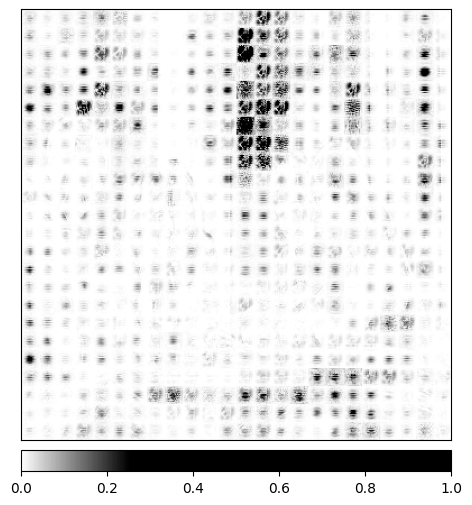

In [ ]:
# Revisualize the attribution instead

default_cmap = LinearSegmentedColormap.from_list('custom blue',
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')], N=256)

# Reshape attributions_ig to (H, W, 1) to make it a 3D array with a single channel
attributions_ig_reshaped = attributions_ig[:, :, np.newaxis]

_ = viz.visualize_image_attr(attributions_ig_reshaped, # Use the reshaped attribution
                             np.array(transformed_img), # Convert PIL image to numpy array
                             method='heat_map',
                             cmap=default_cmap,
                             show_colorbar=True,
                             sign='positive',
                             outlier_perc=1)